In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins, pairwise, reference, did

rng = np.random.default_rng(8)
n = 4000
df = pd.DataFrame({
    "group": rng.choice(["A", "B"], n),
    "preexist": rng.binomial(1, 0.4, n),
    "age": rng.integers(20, 80, n),
})
lp = (-1.5 + 0.6 * (df["group"] == "B") + 0.4 * df["preexist"]
      + 0.5 * ((df["group"] == "B") & (df["preexist"] == 1))
      + 0.02 * df["age"])
df["condX"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm(
    "condX ~ C(group) * C(preexist) + age",
    data=df,
    family=sm.families.Binomial(),
).fit()
m = Margins.linear_scale(fit, at="overall")

In [2]:
scen, w = pairwise("group", ["B", "A"])
print(m.contrasts(scenarios=scen, contrasts=w).summary())

             Margins Result (delta, level=0.95)             
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
group=B    0.1991   0.0150  13.2286  0.000    0.1696, 0.2285

n = 4000
κ: 0.016
Delta-vs-sim disagreement: 0.425%


In [3]:
scen, w_mat = reference(
    "group", levels=["A", "B"], ref_level="A"
)
print(m.contrasts(scenarios=scen, contrasts=w_mat).summary())

             Margins Result (delta, level=0.95)            
        estimate  std err        z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
B_vs_A    0.1991   0.0150  13.2286  0.000    0.1696, 0.2285

n = 4000
κ: max=0.016
Delta-vs-sim disagreement: 0.362%


In [4]:
scen, w = did("group", "preexist",
              treated_level="B", control_level="A",
              post_level=1, pre_level=0)
print(m.contrasts(scenarios=scen, contrasts=w).summary())

           Margins Result (delta, level=0.95)          
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
did    0.0941   0.0304  3.0999  0.002    0.0346, 0.1536

n = 4000
κ: max=0.019
Delta-vs-sim disagreement: 7.192%


/home/hunter/.pyenv/versions/3.12.13/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


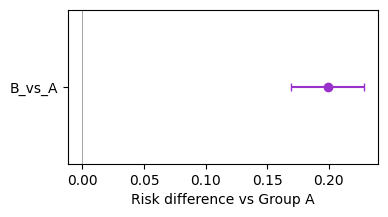

In [5]:
import matplotlib.pyplot as plt
from pymargins import reference

scen, W = reference("group", ["A", "B"], ref_level="A")
res = m.contrasts(scenarios=scen, contrasts=W)
df_forest = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 2))
y = range(len(df_forest))
ax.errorbar(
    df_forest["estimate"], y,
    xerr=[df_forest["estimate"] - df_forest["ci_lower"],
          df_forest["ci_upper"] - df_forest["estimate"]],
    fmt="o", capsize=3, color="darkorchid"
)
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df_forest["label"])
ax.set_xlabel("Risk difference vs Group A")
ax.invert_yaxis()